***Customer Segmentation Analysis (k-Means Clustering Method) by Johny Mohamed***

**Why is Python a powerful tool for marketing analysis?**


Imagine working as a Marketing Analyst for an e-commerce company. Your task is to analyse customer data and segment customers based on income and spending behaviour.



**Why customer segmentation matters**

Customer segmentation helps group customers with similar behavioural patterns. These groups can then support better advertising decisions, more relevant campaign targeting and stronger customer understanding.

**Method used**


For this analysis, we will use K-Means Clustering, a widely used unsupervised machine learning method for customer segmentation. K-Means helps identify natural customer groups based on shared data patterns.

**Process overview**


This notebook walks through a customer segmentation analysis using Python and K-Means Clustering. The workflow includes data preparation, exploratory analysis, cluster creation and interpretation of customer groups.

**Uploading the dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving eshop_Customers.csv to eshop_Customers (1).csv


**Importing the Dependencies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

**Data Collection and Analysis**


In [ ]:
# Loading the data from CSV file to Pandas DataFrame
customer_data = pd.read_csv('/content/eshop_Customers.csv')

In [ ]:
# Printing first 5 rows of DataFrame
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Finding the number of rows and columns in the dataset
customer_data.shape

(200, 5)

In [ ]:
# Some more info about the dataset
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# To verify if there any missing value
customer_data.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**Choosing Annual Score and Pending Score Columns**

In [ ]:
X = customer_data.iloc[:,[3,4]].values

In [ ]:
print (X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

**Choosing the Number of Clusters**

WCSS --> Within Clusters Sum of Squares

In [ ]:
# Finding WCSS value for different number of Clusters using Elbow Method

wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

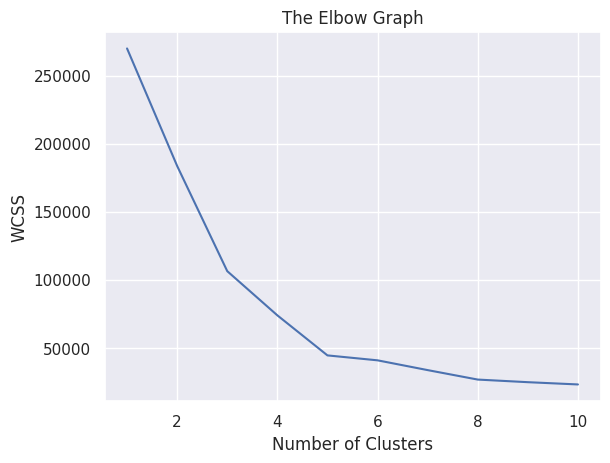

In [ ]:
# Plotting Elbow Graph to find which cluster has minimum value

sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Optimum number of Clusters = 5

**Training the k-Means Clustering Model**

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

# Return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)
print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


**Visualizing all the Clusters**

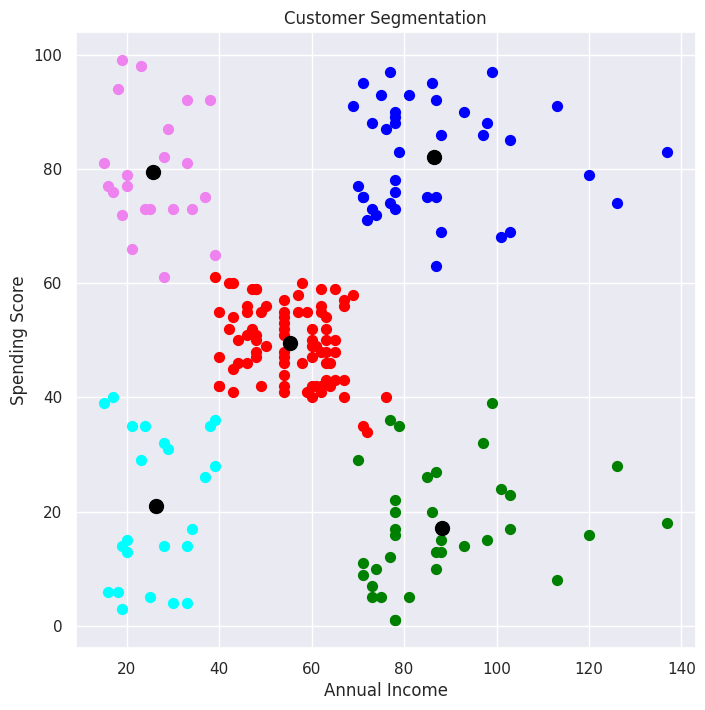

In [ ]:
# Plotting all the clusters and their centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='red', label='Cluster1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='blue', label='Cluster2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='green', label='Cluster3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='cyan', label='Cluster4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='violet', label='Cluster5')

# Plotting the graph
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black', label='Centroids')

plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

**Conclusion**

According the K-means Clutering method of Segmentation, we found 5 segments of customers such as,

Cluster 1(Red) -> High Annual Income but Low Spending Score

Cluster 2 (Blue) -> Medium Annual Income and Medium Spending Score

Cluster 3 (Green) -> High Annual Income and High Spending Score

Cluster 4 (Cyan) -> Low Annual Income but High Spending Score

Cluster 5 (Violet) -> Low Annual Income and Low Spending Score

**Finally, the analysis identified five distinct customer segments, making it easier to design targeted campaigns tailored to each group’s needs, income level and spending behaviour.**